In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
claude_df = pd.read_csv("outputs/claude_results_table.csv")
nova_df = pd.read_csv("outputs/novalite_results_table.csv")
gpt_df = pd.read_csv("outputs/gpt_results_table.csv")

claude_outputs = pd.read_csv("claude_output.csv")
nova_outputs = pd.read_csv("novalite_output.csv")
gpt_outputs = pd.read_csv("gpt_output.csv")

In [22]:
df = pd.concat([claude_df, nova_df, gpt_df])
df_outputs = pd.concat([claude_outputs, nova_outputs, gpt_outputs], ignore_index=True)

In [23]:
measures = [
    "Injections", "Recept_sharing", "Partner_HCV_prop",
    "Withdrawal", "Public_prop", "Drug_out",
    "Treatment", "Alt_route", "Partners"
]
rows = []
for model in df_outputs["Model"].unique():
    df_m = df_outputs[df_outputs["Model"] == model]

    for h in [0, 1]:
        df_h = df_m[df_m["Homeless"] == h]
        rows.append({
            "Model": model,
            "Homeless": h,
            "n": len(df_h),
            "mean_variance": df_h[measures].var(axis=0).mean(),
            "mean_std": df_h[measures].std(axis=0).mean()
        })

variability_df = pd.DataFrame(rows)
print(variability_df)

             Model  Homeless    n  mean_variance  mean_std
0  claudesonnet4.5         0  224      67.647134  5.216131
1  claudesonnet4.5         1  224      69.292439  5.179081
2        nova2lite         0  224      69.767886  5.085522
3        nova2lite         1  224      54.941027  4.344551
4     gpt-oss-120b         0  224      51.613520  3.811402
5     gpt-oss-120b         1  224      50.980457  3.918204


In [29]:
var_map = {
    "Public_prop": "Public or Shelter Use",
    "Withdrawal": "Withdrawals",
    "Recept_sharing": "Receptive Sharing",
    "Partners": "Partner Count",
    "Drug_out": "Distributive Sharing",
    "Partner_HCV_prop": "Partners with HCV",
    "Treatment": "Treatment",
    "Injections": "Injection Frequency",
    "Alt_route": "Alternative Routes",
    "HCV_active": "Positive HCV status"
}

In [31]:
for df in [claude_df, nova_df, gpt_df]:
    df["Variable"] = df["Variable"].replace(var_map)

def prep(df, name):
    return (
        df[["Variable", "Cohens_d", "CI_lower", "CI_upper"]]
        .rename(columns={
            "Cohens_d": f"{name}_d",
            "CI_lower": f"{name}_CI_lower",
            "CI_upper": f"{name}_CI_upper"
        })
    )

claude = prep(claude_df, "Claude")
nova   = prep(nova_df, "Nova")
gpt    = prep(gpt_df, "GPT")

merged = claude.merge(nova, on="Variable").merge(gpt, on="Variable")

for m in ["Claude", "Nova", "GPT"]:
    merged[f"{m}_d"] = merged[f"{m}_d"].clip(-10, 10)

merged["d_spread"] = merged[[f"{m}_d" for m in ["Claude","Nova","GPT"]]].std(axis=1)

merged["max_Δd"] = np.max([
    (merged["Claude_d"] - merged["Nova_d"]).abs(),
    (merged["Claude_d"] - merged["GPT_d"]).abs(),
    (merged["Nova_d"] - merged["GPT_d"]).abs()
], axis=0)

merged["all_same_direction"] = (
    (np.sign(merged["Claude_d"]) == np.sign(merged["Nova_d"])) &
    (np.sign(merged["Claude_d"]) == np.sign(merged["GPT_d"]))
)

merged = merged.sort_values("d_spread", ascending=False)

for m in ["Claude", "Nova", "GPT"]:
    merged[f"CI_{m}"] = (
        "(" + merged[f"{m}_CI_lower"].round(2).astype(str)
        + ", " +
        merged[f"{m}_CI_upper"].round(2).astype(str)
        + ")"
    )

final_table = pd.DataFrame({
    ("", "Variable"): merged["Variable"],
    ("GPT", "Cohen's d"): merged["GPT_d"],
    ("GPT", "CI"): merged["CI_GPT"],
    ("Claude", "Cohen's d"): merged["Claude_d"],
    ("Claude", "CI"): merged["CI_Claude"],
    ("Nova", "Cohen's d"): merged["Nova_d"],
    ("Nova", "CI"): merged["CI_Nova"],
    ("Comparison", "Model SD"): merged["d_spread"],
    ("Comparison", "Same Direction"): merged["all_same_direction"]
})

final_table.columns = pd.MultiIndex.from_tuples(final_table.columns)
final_table

GPT                    Claude                  \
                Variable Cohen's d              CI Cohen's d              CI   
0  Public or Shelter Use  3.941642     (0.5, 0.53)  3.941642     (0.5, 0.53)   
9              Treatment -0.311402  (-0.16, -0.07) -0.311402  (-0.16, -0.07)   
8     Alternative Routes -0.257770   (-0.31, -0.1) -0.257770   (-0.31, -0.1)   
7    Injection Frequency -0.237528  (-1.37, -0.42) -0.237528  (-1.37, -0.42)   
2          Partner Count  0.146240     (0.01, 0.2)  0.146240     (0.01, 0.2)   
5      Partners with HCV -0.134538    (-0.0, -0.0) -0.134538    (-0.0, -0.0)   
3      Receptive Sharing  0.128899    (0.06, 1.07)  0.128899    (0.06, 1.07)   
1    Positive HCV status  0.226744    (0.02, 0.08)  0.226744    (0.02, 0.08)   
6            Withdrawals -0.152516  (-0.35, -0.03) -0.152516  (-0.35, -0.03)   
4   Distributive Sharing -0.045140   (-0.48, 0.23) -0.045140   (-0.48, 0.23)   

       Nova                Comparison                 
  Cohen's d             CI   Model SD Same Direction  
0  1.121978   (0.29, 0.36)   1.627934           True  
9  0.000000     (0.0, 0.0)   0.179788          False  
8  0.000000     (0.0, 0.0)   0.148824          False  
7  0.018493  (-0.08, 0.12)   0.147814          False  
2 -0.056945  (-0.06, 0.02)   0.117309          False  
5  0.000000     (0.0, 0.0)   0.077676          False  
3  0.023504  (-0.03, 0.04)   0.060850           True  
1  0.134539    (0.0, 0.04)   0.053235           True  
6 -0.080444  (-0.35, 0.06)   0.041610           True  
4 -0.070039   (-2.5, 0.39)   0.014375           True

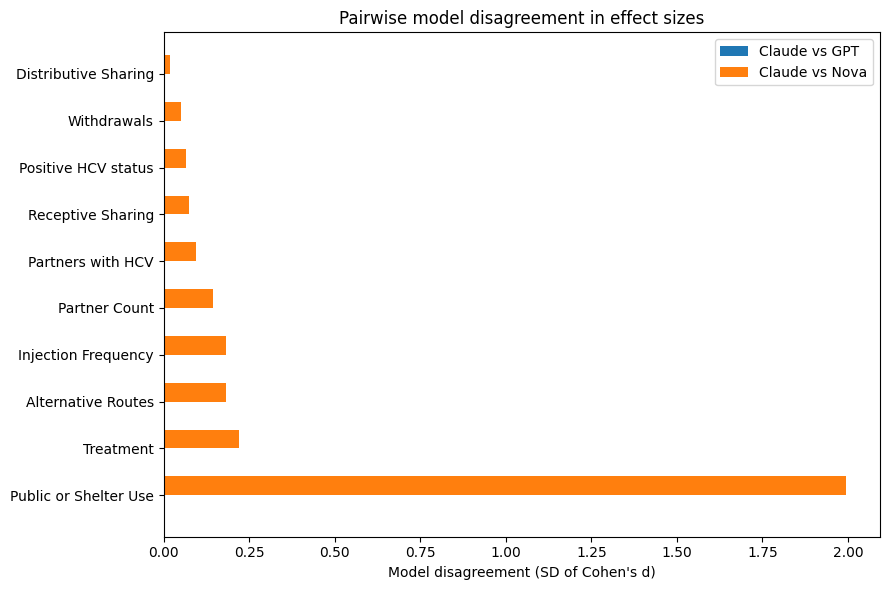

In [ ]:
plot_df = merged.copy()

plot_df["d_spread_CG"] = plot_df[["Claude_d", "GPT_d"]].std(axis=1)
plot_df["d_spread_CN"] = plot_df[["Claude_d", "Nova_d"]].std(axis=1)

plot_df = plot_df.sort_values("d_spread_CG", ascending=True)
y = np.arange(len(plot_df))
plt.figure(figsize=(9, 6))

plt.barh(y - 0.2, plot_df["d_spread_CG"], height=0.4, label="Claude vs GPT")
plt.barh(y + 0.2, plot_df["d_spread_CN"], height=0.4, label="Claude vs Nova")

plt.yticks(y, plot_df["Variable"])
plt.xlabel("Model disagreement (SD of Cohen's d)")
plt.title("Pairwise model disagreement in effect sizes")

plt.legend()
plt.tight_layout()
plt.show()

In [32]:
latex_table = final_table.to_latex(
    index=False,
    multicolumn=True,
    multirow=True,
    escape=False,
    column_format="lccc ccc cc",
    float_format="%.2f",   
    caption="Comparison of Claude and Nova model estimates",
    label="tab:model_comparison"
)
print(latex_table)

\begin{table}
\caption{Comparison of Claude and Nova model estimates}
\label{tab:model_comparison}
\begin{tabular}{lccc ccc cc}
\toprule
 & \multicolumn{2}{r}{GPT} & \multicolumn{2}{r}{Claude} & \multicolumn{2}{r}{Nova} & \multicolumn{2}{r}{Comparison} \\
Variable & Cohen's d & CI & Cohen's d & CI & Cohen's d & CI & Model SD & Same Direction \\
\midrule
Public or Shelter Use & 3.94 & (0.5, 0.53) & 3.94 & (0.5, 0.53) & 1.12 & (0.29, 0.36) & 1.63 & True \\
Treatment & -0.31 & (-0.16, -0.07) & -0.31 & (-0.16, -0.07) & 0.00 & (0.0, 0.0) & 0.18 & False \\
Alternative Routes & -0.26 & (-0.31, -0.1) & -0.26 & (-0.31, -0.1) & 0.00 & (0.0, 0.0) & 0.15 & False \\
Injection Frequency & -0.24 & (-1.37, -0.42) & -0.24 & (-1.37, -0.42) & 0.02 & (-0.08, 0.12) & 0.15 & False \\
Partner Count & 0.15 & (0.01, 0.2) & 0.15 & (0.01, 0.2) & -0.06 & (-0.06, 0.02) & 0.12 & False \\
Partners with HCV & -0.13 & (-0.0, -0.0) & -0.13 & (-0.0, -0.0) & 0.00 & (0.0, 0.0) & 0.08 & False \\
Receptive Sharing & 0.13 & 